# HW15: CNN

In [50]:
%matplotlib inline
import warnings
import pandas as pd
import numpy as np
from keras.datasets import cifar10
from keras.models import Sequential
from keras.models import load_model
from keras.layers import (
    Dense,
    Flatten,
    Dropout,
    Conv2D,
    MaxPooling2D,
    Activation,
    BatchNormalization
)
from keras.utils import np_utils
from keras.preprocessing import image
import matplotlib.pyplot as plt
from PIL import Image
from keras.datasets import mnist
from keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

In [1]:
%load_ext pycodestyle_magic

In [4]:
config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
session = tf.compat.v1.Session(config=config)

In [5]:
def plot_history(history):
    history_dict = history.history
    loss_values = history_dict['loss']
    val_loss_values = history_dict['val_loss']
    epochs = range(1, len(loss_values) + 1)


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    ax1.plot(epochs, loss_values, 'bo',
             label='Training loss')
    ax1.plot(epochs, val_loss_values, 'b',
             label='Validation loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.set_xscale('log')

    acc_values = history_dict['accuracy']
    val_acc_values = history_dict['val_accuracy']

    ax2.plot(epochs, acc_values, 'bo',
             label='Training acc')
    ax2.plot(epochs, val_acc_values, 'b',
             label='Validation acc')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.set_xscale('log')


    plt.legend()
    plt.show()

## Import

In [6]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

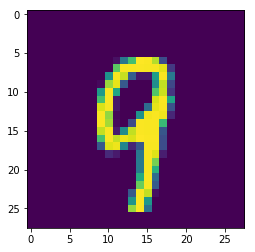

This is a 9


In [7]:
n = np.random.randint(X_train.shape[0])
plt.imshow(Image.fromarray(X_train[n]))
plt.show()
print(f'This is a {y_train[n]}')

Reshaping the data to fit into the keras image format:
(samples, rows, cols, channels)

In [8]:
X_train = X_train[:,:,:,None]
X_test = X_test[:,:,:,None]

In [9]:
X_train.shape

(60000, 28, 28, 1)

Defining some parameters:

In [10]:
batch_size = 32
num_samples = X_train.shape[0]
num_classes = np.unique(y_train).shape[0]
num_epochs = 10
img_rows, img_cols = X_train[0,:,:,0].shape
img_channels = 1
classes = np.unique(y_train)

In [11]:
y_train = np_utils.to_categorical(y_train, num_classes)
y_test = np_utils.to_categorical(y_test, num_classes)

Standardizing the data:

In [12]:
X_train_norm = X_train.astype('float32')
X_test_norm = X_test.astype('float32')
X_train_norm /= 255
X_test_norm /= 255

## Model

### Defining some straightforward architecture

In [13]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3, 3),
                 activation='relu',
                 input_shape=(28, 28, 1)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [14]:
history = model.fit(
    X_train_norm,
    y_train,
    batch_size=batch_size,
    epochs=num_epochs,
    validation_split=0.1,
    shuffle=True
)

Train on 54000 samples, validate on 6000 samples
Epoch 1/10
54000/54000 [==============================] - 13s 239us/step - loss: 0.0332 - accuracy: 0.9888 - val_loss: 0.0079 - val_accuracy: 0.9975
Epoch 2/10
54000/54000 [==============================] - 12s 225us/step - loss: 0.0148 - accuracy: 0.9952 - val_loss: 0.0066 - val_accuracy: 0.9976
Epoch 3/10
54000/54000 [==============================] - 12s 225us/step - loss: 0.0113 - accuracy: 0.9963 - val_loss: 0.0070 - val_accuracy: 0.9978
Epoch 4/10
54000/54000 [==============================] - 12s 227us/step - loss: 0.0094 - accuracy: 0.9969 - val_loss: 0.0057 - val_accuracy: 0.9982
Epoch 5/10
54000/54000 [==============================] - 12s 227us/step - loss: 0.0079 - accuracy: 0.9973 - val_loss: 0.0068 - val_accuracy: 0.9980
Epoch 6/10
54000/54000 [==============================] - 12s 227us/step - loss: 0.0067 - accuracy: 0.9978 - val_loss: 0.0058 - val_accuracy: 0.9981
Epoch 7/10
54000/54000 [==============================] -

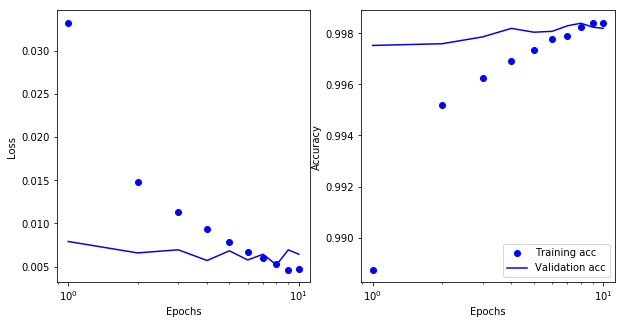

In [15]:
plot_history(history)

In [ ]:
! mkdir newer

In [19]:
model.save('newer/simple.h5')

### Adding batch normalization

In [20]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3, 3),
                 activation='relu',
                 input_shape=(28, 28, 1)))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [21]:
history1 = model.fit(
    X_train_norm,
    y_train,
    batch_size=batch_size,
    epochs=num_epochs,
    validation_split=0.1,
    shuffle=True
)

Train on 54000 samples, validate on 6000 samples
Epoch 1/10
54000/54000 [==============================] - 23s 417us/step - loss: 0.0652 - accuracy: 0.9796 - val_loss: 0.0127 - val_accuracy: 0.9962
Epoch 2/10
54000/54000 [==============================] - 22s 406us/step - loss: 0.0308 - accuracy: 0.9905 - val_loss: 0.0090 - val_accuracy: 0.9976
Epoch 3/10
54000/54000 [==============================] - 22s 411us/step - loss: 0.0234 - accuracy: 0.9927 - val_loss: 0.0113 - val_accuracy: 0.9967
Epoch 4/10
54000/54000 [==============================] - 23s 417us/step - loss: 0.0206 - accuracy: 0.9938 - val_loss: 0.0088 - val_accuracy: 0.9976
Epoch 5/10
54000/54000 [==============================] - 22s 409us/step - loss: 0.0167 - accuracy: 0.9948 - val_loss: 0.0082 - val_accuracy: 0.9978
Epoch 6/10
54000/54000 [==============================] - 22s 415us/step - loss: 0.0149 - accuracy: 0.9953 - val_loss: 0.0079 - val_accuracy: 0.9978
Epoch 7/10
54000/54000 [==============================] -

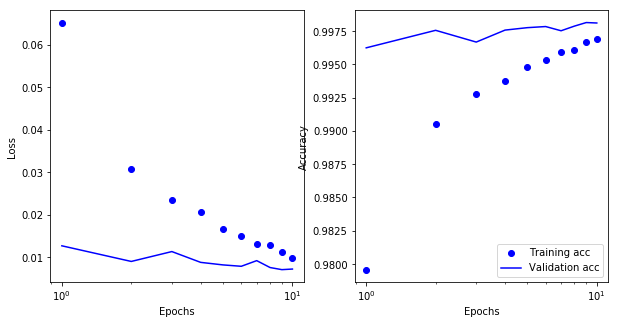

In [22]:
plot_history(history1)

In [23]:
model.save('newer/simple+batch.h5')

### Adding more convolutional layers

In [25]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3, 3),
                 activation='relu',
                 input_shape=(28, 28, 1)))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))


model.add(Conv2D(64, kernel_size=(3, 3),
                 activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [26]:
history2 = model.fit(
    X_train_norm,
    y_train,
    batch_size=batch_size,
    epochs=num_epochs,
    validation_split=0.1,
    shuffle=True
)

Train on 54000 samples, validate on 6000 samples
Epoch 1/10
54000/54000 [==============================] - 27s 506us/step - loss: 0.0449 - accuracy: 0.9855 - val_loss: 0.0105 - val_accuracy: 0.9967
Epoch 2/10
54000/54000 [==============================] - 26s 478us/step - loss: 0.0205 - accuracy: 0.9939 - val_loss: 0.0065 - val_accuracy: 0.9981
Epoch 3/10
54000/54000 [==============================] - 26s 479us/step - loss: 0.0165 - accuracy: 0.9950 - val_loss: 0.0072 - val_accuracy: 0.9978
Epoch 4/10
54000/54000 [==============================] - 26s 477us/step - loss: 0.0144 - accuracy: 0.9959 - val_loss: 0.0061 - val_accuracy: 0.9984
Epoch 5/10
54000/54000 [==============================] - 26s 483us/step - loss: 0.0126 - accuracy: 0.9964 - val_loss: 0.0061 - val_accuracy: 0.9984
Epoch 6/10
54000/54000 [==============================] - 26s 479us/step - loss: 0.0107 - accuracy: 0.9968 - val_loss: 0.0070 - val_accuracy: 0.9981
Epoch 7/10
54000/54000 [==============================] -

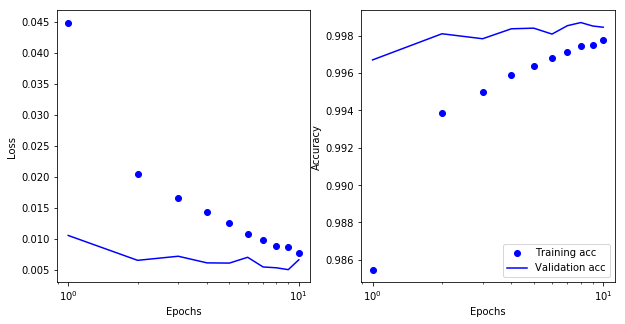

In [27]:
plot_history(history2)

In [28]:
model.save('newer/32+64_64+128.h5')

Another variant:

In [29]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3, 3),
                 activation='relu',
                 input_shape=(28, 28, 1)))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(64, (5, 5), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [30]:
history3 = model.fit(
    X_train_norm,
    y_train,
    batch_size=batch_size,
    epochs=num_epochs,
    validation_split=0.1,
    shuffle=True
)

Train on 54000 samples, validate on 6000 samples
Epoch 1/10
54000/54000 [==============================] - 32s 599us/step - loss: 0.0489 - accuracy: 0.9847 - val_loss: 0.0105 - val_accuracy: 0.9969
Epoch 2/10
54000/54000 [==============================] - 32s 585us/step - loss: 0.0252 - accuracy: 0.9926 - val_loss: 0.0110 - val_accuracy: 0.9976
Epoch 3/10
54000/54000 [==============================] - 31s 581us/step - loss: 0.0191 - accuracy: 0.9943 - val_loss: 0.0128 - val_accuracy: 0.9967
Epoch 4/10
54000/54000 [==============================] - 32s 585us/step - loss: 0.0164 - accuracy: 0.9953 - val_loss: 0.0070 - val_accuracy: 0.9982
Epoch 5/10
54000/54000 [==============================] - 31s 582us/step - loss: 0.0136 - accuracy: 0.9960 - val_loss: 0.0070 - val_accuracy: 0.9981
Epoch 6/10
54000/54000 [==============================] - 31s 583us/step - loss: 0.0116 - accuracy: 0.9967 - val_loss: 0.0064 - val_accuracy: 0.9984
Epoch 7/10
54000/54000 [==============================] -

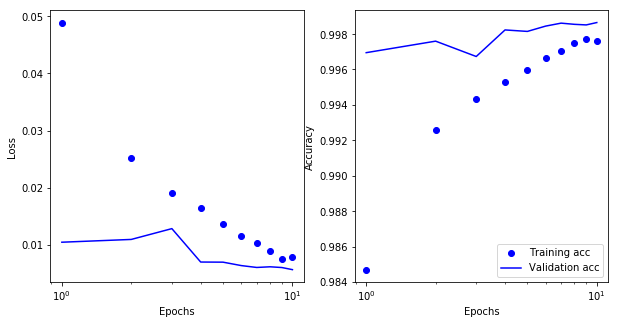

In [31]:
plot_history(history3)

In [32]:
model.save('newer/32+64+64.h5')

Adding more layers doesn't seem to change anything. Adding more nodes...

### Adding more nodes to existing layers:

In [33]:
model = Sequential()

model.add(Conv2D(64, kernel_size=(3, 3),
                 activation='relu',
                 input_shape=(28, 28, 1)))
model.add(BatchNormalization())
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [34]:
history4 = model.fit(
    X_train_norm,
    y_train,
    batch_size=batch_size,
    epochs=num_epochs,
    validation_split=0.1,
    shuffle=True
)

Train on 54000 samples, validate on 6000 samples
Epoch 1/10
54000/54000 [==============================] - 41s 755us/step - loss: 0.0893 - accuracy: 0.9729 - val_loss: 0.0192 - val_accuracy: 0.9946
Epoch 2/10
54000/54000 [==============================] - 40s 735us/step - loss: 0.0443 - accuracy: 0.9868 - val_loss: 0.0156 - val_accuracy: 0.9958
Epoch 3/10
54000/54000 [==============================] - 40s 740us/step - loss: 0.0347 - accuracy: 0.9896 - val_loss: 0.0109 - val_accuracy: 0.9970
Epoch 4/10
54000/54000 [==============================] - 40s 740us/step - loss: 0.0289 - accuracy: 0.9912 - val_loss: 0.0121 - val_accuracy: 0.9972
Epoch 5/10
54000/54000 [==============================] - 40s 740us/step - loss: 0.0262 - accuracy: 0.9921 - val_loss: 0.0106 - val_accuracy: 0.9974
Epoch 6/10
54000/54000 [==============================] - 40s 737us/step - loss: 0.0224 - accuracy: 0.9932 - val_loss: 0.0117 - val_accuracy: 0.9969
Epoch 7/10
54000/54000 [==============================] -

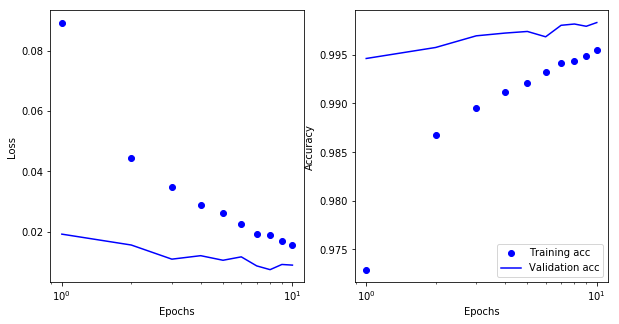

In [35]:
plot_history(history4)

In [37]:
model.save('newer/64+128.h5')

### More nodes & more layers:

In [38]:
model = Sequential()

model.add(Conv2D(64, kernel_size=(3, 3),
                 activation='relu',
                 input_shape=(28, 28, 1)))
model.add(BatchNormalization())
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))


model.add(Conv2D(256, kernel_size=(3, 3),
                 activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(512, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [39]:
history5 = model.fit(
    X_train_norm,
    y_train,
    batch_size=batch_size,
    epochs=num_epochs,
    validation_split=0.1,
    shuffle=True
)

Train on 54000 samples, validate on 6000 samples
Epoch 1/10
54000/54000 [==============================] - 73s 1ms/step - loss: 0.0754 - accuracy: 0.9745 - val_loss: 0.0128 - val_accuracy: 0.9961
Epoch 2/10
54000/54000 [==============================] - 75s 1ms/step - loss: 0.0383 - accuracy: 0.9874 - val_loss: 0.0111 - val_accuracy: 0.9969
Epoch 3/10
54000/54000 [==============================] - 75s 1ms/step - loss: 0.0296 - accuracy: 0.9906 - val_loss: 0.0074 - val_accuracy: 0.9980
Epoch 4/10
54000/54000 [==============================] - 75s 1ms/step - loss: 0.0249 - accuracy: 0.9922 - val_loss: 0.0079 - val_accuracy: 0.9980
Epoch 5/10
54000/54000 [==============================] - 75s 1ms/step - loss: 0.0213 - accuracy: 0.9935 - val_loss: 0.0083 - val_accuracy: 0.9982
Epoch 6/10
54000/54000 [==============================] - 75s 1ms/step - loss: 0.0181 - accuracy: 0.9945 - val_loss: 0.0071 - val_accuracy: 0.9984
Epoch 7/10
54000/54000 [==============================] - 75s 1ms/ste

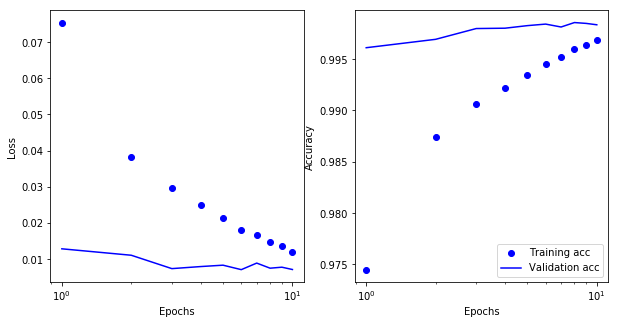

In [40]:
plot_history(history5)

In [41]:
model.save('newer/64+128_256+512.h5')

### Slightly changing the output layer configuration:

In [42]:
model = Sequential()

model.add(Conv2D(64, kernel_size=(3, 3),
                 activation='relu',
                 input_shape=(28, 28, 1)))
model.add(BatchNormalization())
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))


model.add(Conv2D(256, kernel_size=(3, 3),
                 activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(512, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(512))
model.add(BatchNormalization())
model.add(Dense(256))
model.add(BatchNormalization())
model.add(Dense(128))
model.add(BatchNormalization())
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [43]:
history6 = model.fit(
    X_train_norm,
    y_train,
    batch_size=batch_size,
    epochs=num_epochs,
    validation_split=0.1,
    shuffle=True
)

Train on 54000 samples, validate on 6000 samples
Epoch 1/10
54000/54000 [==============================] - 90s 2ms/step - loss: 0.0198 - accuracy: 0.9933 - val_loss: 0.0078 - val_accuracy: 0.9975
Epoch 2/10
54000/54000 [==============================] - 90s 2ms/step - loss: 0.0098 - accuracy: 0.9967 - val_loss: 0.0073 - val_accuracy: 0.9975
Epoch 3/10
54000/54000 [==============================] - 145s 3ms/step - loss: 0.0079 - accuracy: 0.9974 - val_loss: 0.0041 - val_accuracy: 0.9987
Epoch 4/10
54000/54000 [==============================] - 151s 3ms/step - loss: 0.0067 - accuracy: 0.9978 - val_loss: 0.0051 - val_accuracy: 0.9985
Epoch 5/10
54000/54000 [==============================] - 153s 3ms/step - loss: 0.0058 - accuracy: 0.9980 - val_loss: 0.0065 - val_accuracy: 0.9978
Epoch 6/10
54000/54000 [==============================] - 155s 3ms/step - loss: 0.0049 - accuracy: 0.9984 - val_loss: 0.0046 - val_accuracy: 0.9986
Epoch 7/10
54000/54000 [==============================] - 157s 3m

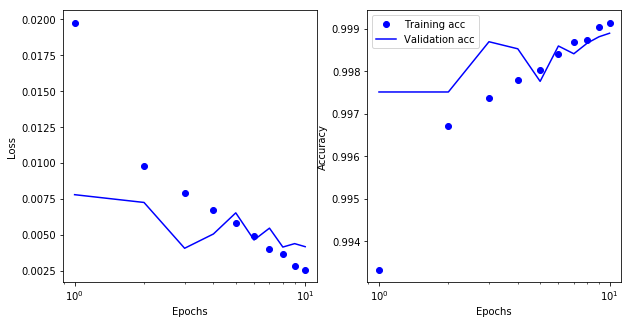

In [44]:
plot_history(history6)

In [45]:
model.save('newer/64+128_256+512_diff_fcnn.h5')

### Plotting everything together

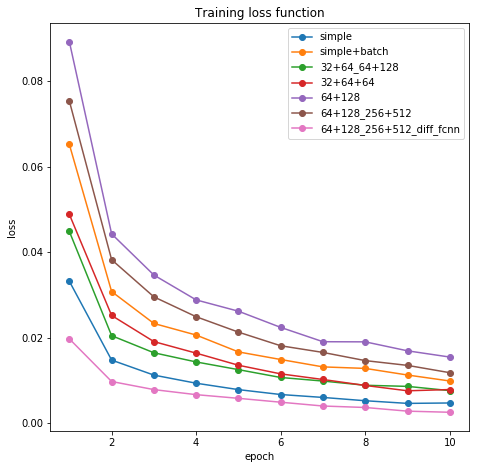

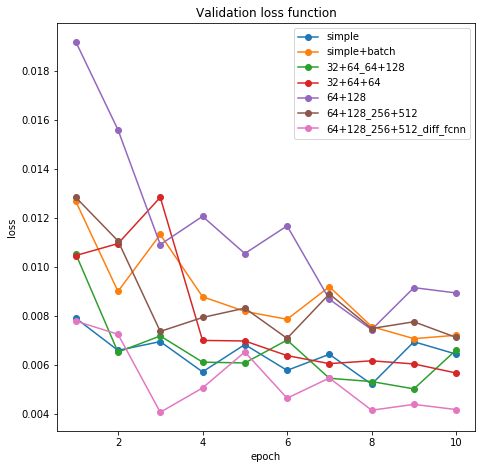

In [48]:
labels = ['simple', 'simple+batch', '32+64_64+128',
          '32+64+64', '64+128', '64+128_256+512', '64+128_256+512_diff_fcnn']
plt.figure(figsize=(7.5,7.5))
for idx, h in enumerate([history, history1, history2,
          history3, history4, history5, history6]):
    history_dict = h.history
    loss_values = history_dict['loss']
    epochs = range(1, len(loss_values) + 1)
    
    plt.plot(epochs, loss_values, label=labels[idx],
             linestyle='-', marker='o')

plt.title('Training loss function')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()


plt.figure(figsize=(7.5,7.5))
for idx, h in enumerate([history, history1, history2,
          history3, history4, history5, history6]):
    history_dict = h.history
    loss_values = history_dict['val_loss']
    epochs = range(1, len(loss_values) + 1)
    
    plt.plot(epochs, loss_values, label=labels[idx],
             linestyle='-', marker='o')

plt.title('Validation loss function')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

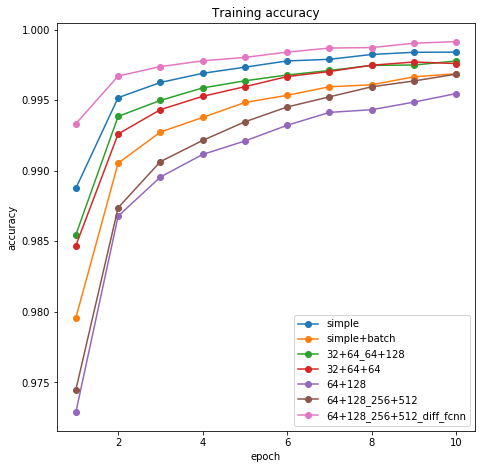

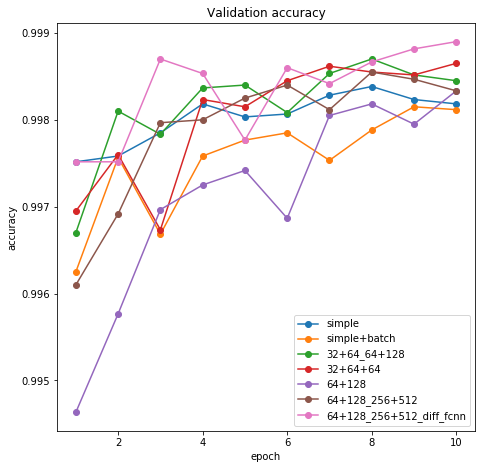

In [49]:
labels = ['simple', 'simple+batch', '32+64_64+128',
'32+64+64', '64+128', '64+128_256+512', '64+128_256+512_diff_fcnn']
plt.figure(figsize=(7.5,7.5))
for idx, h in enumerate([history, history1, history2,
          history3, history4, history5, history6]):
    history_dict = h.history
    acc_values = history_dict['accuracy']
    epochs = range(1, len(loss_values) + 1)
    
    plt.plot(epochs, acc_values, label=labels[idx],
             linestyle='-', marker='o')

plt.title('Training accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()


plt.figure(figsize=(7.5,7.5))
for idx, h in enumerate([history, history1, history2,
          history3, history4, history5, history6]):
    history_dict = h.history
    acc_values = history_dict['val_accuracy']
    epochs = range(1, len(loss_values) + 1)
    
    plt.plot(epochs, acc_values, label=labels[idx],
             linestyle='-', marker='o')

plt.title('Validation accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()

### Looks like the last variant was the best one

So, training it for another 5 epochs

In [51]:
model = load_model('newer/64+128_256+512_diff_fcnn.h5')

In [53]:
history_final = model.fit(
    X_train_norm,
    y_train,
    batch_size=batch_size,
    epochs=5,
    validation_split=0.1,
    shuffle=True
)

Train on 54000 samples, validate on 6000 samples
Epoch 1/5
54000/54000 [==============================] - 83s 2ms/step - loss: 0.0025 - accuracy: 0.9991 - val_loss: 0.0037 - val_accuracy: 0.9989
Epoch 2/5
54000/54000 [==============================] - 81s 1ms/step - loss: 0.0025 - accuracy: 0.9992 - val_loss: 0.0047 - val_accuracy: 0.9989
Epoch 3/5
54000/54000 [==============================] - 80s 1ms/step - loss: 0.0015 - accuracy: 0.9995 - val_loss: 0.0046 - val_accuracy: 0.9988
Epoch 4/5
54000/54000 [==============================] - 81s 1ms/step - loss: 0.0020 - accuracy: 0.9993 - val_loss: 0.0048 - val_accuracy: 0.9988
Epoch 5/5
54000/54000 [==============================] - 81s 1ms/step - loss: 0.0015 - accuracy: 0.9995 - val_loss: 0.0033 - val_accuracy: 0.9991


Seems slightly better, evaluating the test score:

In [63]:
model.evaluate(X_test_norm, y_test)

10000/10000 [==============================] - 3s 335us/step


[0.004107108530049117, 0.9990098476409912]

Comparing it to the test score of the __simplest__ model:

In [60]:
model_simple = load_model('newer/simple.h5')

In [64]:
model_simple.evaluate(X_test_norm, y_test)

10000/10000 [==============================] - 1s 74us/step


[0.0058226157868856605, 0.9982296824455261]